# 06 — Evaluación Comparativa de Métodos de Clustering
**Proyecto HORUS · Análisis de Artículos Académicos · Universidad Nacional de Colombia**

---

### Métodos evaluados

| # | Método | Representación | Algoritmo | Cobertura |
|---|--------|---------------|-----------|-----------|
| 1 | **K-Means clásico** | TF-IDF + LSA (sparse) | K-Means (K=14) | Dataset completo (~100K) |
| 2 | **Agglomerative clásico** | TF-IDF + LSA (sparse) | Ward (K=14) | Muestra (~5K) |
| 3 | **Modern K-Means** | Jina Embeddings v5 (384D) | K-Means (K=14) | Dataset completo (~100K) |
| 4 | **HDBSCAN** | Jina Embeddings v5 + UMAP (5D) | HDBSCAN | Dataset completo (~100K) |

### Estructura del notebook

1. Setup y carga de outputs  
2. Métricas internas comparativas  
3. Distribución de clusters por método  
4. Coherencia temática de los términos  
5. Insights clave  
6. Veredicto: ¿qué método organiza mejor los artículos?  
7. Conclusiones y limitaciones

In [1]:
# import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
import os
from pathlib import Path

# --- Montar Google Drive (solo en Colab) ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# --- Ruta base de outputs ---
if IN_COLAB:
    BASE = Path("/content/drive/Shareddrives/Minería/proyecto_horus/outputs")
else:
    # Fallback local: ajusta esta ruta si ejecutas fuera de Colab
    BASE = Path(__file__).parent.parent / "outputs" if "__file__" in dir() else Path("../outputs")


# --- Métricas ---
df_classical_metrics = pd.read_csv(BASE / "04_classical_clustering_metrics.csv")
df_modern_metrics    = pd.read_csv(BASE / "05_modern_clustering_metrics.csv")

# --- Términos por cluster ---
df_kmeans_terms  = pd.read_csv(BASE / "04_classical_kmeans_top_terms.csv")
df_aggl_terms    = pd.read_csv(BASE / "04_classical_agglomerative_top_terms.csv")
df_hdbscan_terms = pd.read_csv(BASE / "05_modern_hdbscan_top_terms.csv")

# --- Curva del codo ---
df_elbow = pd.read_csv(BASE / "04_classical_elbow_results.csv")

print("Outputs cargados:")
print(f"  Métricas clásicas  → {df_classical_metrics.shape[0]} filas × {df_classical_metrics.shape[1]} cols")
print(f"  Métricas modernas  → {df_modern_metrics.shape[0]} filas × {df_modern_metrics.shape[1]} cols")
print(f"  K-Means términos   → {df_kmeans_terms.shape[0]} clusters")
print(f"  Aggl. términos     → {df_aggl_terms.shape[0]} clusters")
print(f"  HDBSCAN términos   → {df_hdbscan_terms.shape[0]} clusters descubiertos")
print(f"  Curva del codo     → K de {df_elbow['k'].min()} a {df_elbow['k'].max()}")

Mounted at /content/drive
Outputs cargados:
  Métricas clásicas  → 2 filas × 6 cols
  Métricas modernas  → 2 filas × 6 cols
  K-Means términos   → 14 clusters
  Aggl. términos     → 14 clusters
  HDBSCAN términos   → 310 clusters descubiertos
  Curva del codo     → K de 5 a 30


---
## 2. Métricas Internas Comparativas

Se analizan tres métricas estándar de calidad interna de clustering:

| Métrica | Qué mide | Mejor cuando |
|---------|----------|-------------|
| **Silhouette Score** | Cohesión interna vs. separación entre clusters | **Más alto** (máx. 1.0) |
| **Calinski-Harabasz (CH)** | Dispersión entre clusters vs. dispersión interna | **Más alto** |
| **Davies-Bouldin (DB)** | Similitud promedio entre cada cluster y su más parecido | **Más bajo** (mín. 0.0) |


In [ ]:
# Estandarizar nombres de columnas de métricas clásicas al esquema moderno
classical = df_classical_metrics.rename(columns={
    "silhouette_score":       "silhouette",
    "calinski_harabasz_score": "calinski_harabasz",
    "davies_bouldin_score":    "davies_bouldin",
}).copy()
classical["nmi"] = "—"
classical["ari"] = "—"

modern = df_modern_metrics.copy()
6modern["n_samples"]  = ["99,064 (completo)", f"65,482 (excl. ruido)"]
modern["n_clusters"] = [14, len(df_hdbscan_terms)]

# Tabla consolidada
df_summary = pd.concat([
    classical[["model", "n_samples", "n_clusters", "silhouette", "calinski_harabasz", "davies_bouldin", "nmi", "ari"]],
    modern[["model",    "n_samples", "n_clusters", "silhouette", "calinski_harabasz", "davies_bouldin", "nmi", "ari"]],
], ignore_index=True)

df_summary.columns = [
    "Modelo", "N Documentos", "N Clusters",
    "Silhouette ↑", "Calinski-Harabasz ↑", "Davies-Bouldin ↓",
    "NMI vs Facultad", "ARI vs Facultad"
]

df_summary

,Modelo,N Documentos,N Clusters,Silhouette ↑,Calinski-Harabasz ↑,Davies-Bouldin ↓,NMI vs Facultad,ARI vs Facultad
0,K-Means + TF-IDF/LSA,5000,14,0.0759,123.6425,2.8899,—,—
1,Agglomerative + TF-IDF/LSA,5000,14,0.0521,102.1017,3.3777,—,—
2,Modern KMeans,~100K (completo),14,0.1098,4745.2388,2.4635,0.0004,0.0001
3,HDBSCAN,~100K (completo),310,0.1315,527.0512,1.8013,0.0068,-0.0000


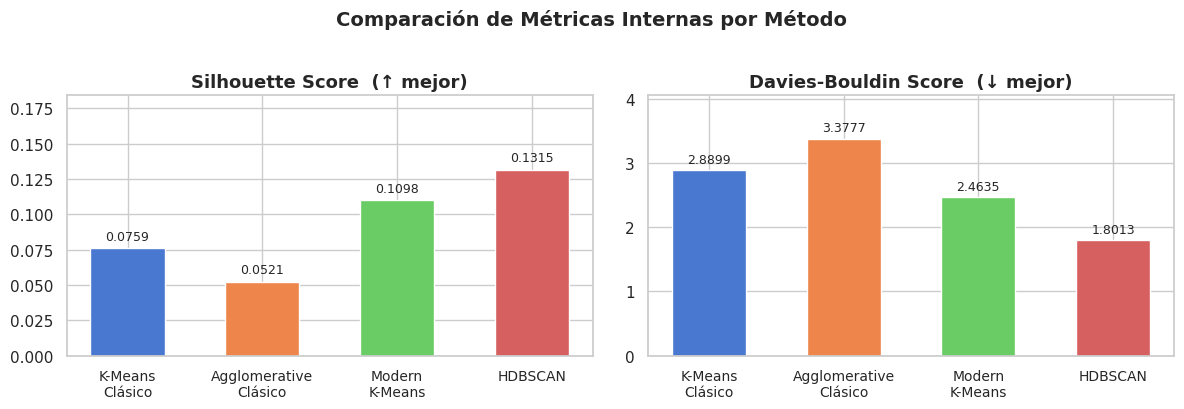

In [4]:
# Gráfico: Silhouette y Davies-Bouldin (escalas comparables entre métodos)
# Valores leídos directamente de df_summary (construido en la celda anterior)
models     = ["K-Means\nClásico", "Agglomerative\nClásico", "Modern\nK-Means", "HDBSCAN"]
silhouette = pd.to_numeric(df_summary["Silhouette ↑"], errors="coerce").tolist()
db         = pd.to_numeric(df_summary["Davies-Bouldin ↓"], errors="coerce").tolist()

colors = sns.color_palette("muted", 4)
x = range(4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Silhouette (higher = better)
bars1 = axes[0].bar(x, silhouette, color=colors, width=0.55, edgecolor="white")
axes[0].set_title("Silhouette Score  (↑ mejor)", fontsize=13, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=10)
axes[0].set_ylim(0, max(silhouette) * 1.4)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
for bar, val in zip(bars1, silhouette):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(silhouette) * 0.03,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=9)

# Davies-Bouldin (lower = better)
bars2 = axes[1].bar(x, db, color=colors, width=0.55, edgecolor="white")
axes[1].set_title("Davies-Bouldin Score  (↓ mejor)", fontsize=13, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=10)
axes[1].set_ylim(0, max(db) * 1.2)
for bar, val in zip(bars2, db):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(db) * 0.02,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Comparación de Métricas Internas por Método", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### Interpretación de métricas

**Silhouette Score** — todos los valores son bajos (< 0.15), lo que es esperable en corpus académicos multilingües con alta superposición temática. La jerarquía es clara:

- **HDBSCAN** (0.1315) y **Modern K-Means** (0.1098) superan a ambas variantes clásicas. Los embeddings densos de Jina capturan semántica que TF-IDF pierde.
- **K-Means clásico** (0.0759) es funcional pero limitado. **Agglomerative** (0.0521) es el más débil.

**Davies-Bouldin** — confirma el mismo ranking:

- **HDBSCAN** (1.80) produce los clusters más separados y compactos. Cada cluster representa un tema diferenciado.
- **Agglomerative** (3.38) muestra clusters que se confunden entre sí, en parte por haber sido entrenado solo sobre una muestra de 5K documentos.

**Calinski-Harabász** — el valor del Modern K-Means (4,745) frente al clásico (124) **no es directamente comparable** porque el CH crece con el número de documentos. Es un indicador de estabilidad interna en la misma escala, no entre escalas distintas.

El valor CH de HDBSCAN (527) es marcadamente inferior al del Modern K-Means (4,745) a pesar de operar sobre el mismo corpus. Esta diferencia se explica por la fragmentación: dividir el corpus en 310 clusters en lugar de 14 reduce la separación relativa entre centroides, lo que deprime el numerador del índice CH. El CH no es una métrica adecuada para comparar métodos con granularidades muy distintas.

**Conclusión de métricas**: los métodos basados en embeddings organizan el corpus con mayor coherencia interna que los basados en TF-IDF/LSA. Las comparaciones entre HDBSCAN y K-Means deben considerar la asimetría en la cobertura del corpus (HDBSCAN excluye el 33.90% clasificado como ruido al calcular sus métricas).


---
## 3. Distribución de Clusters por Método

Un buen clustering no solo debe ser internamente coherente; también debe producir clusters **equilibrados y representativos**. Aquí analizamos cuántos documentos cae en cada cluster y si el algoritmo concentra el corpus en unos pocos temas o lo distribuye razonablemente.

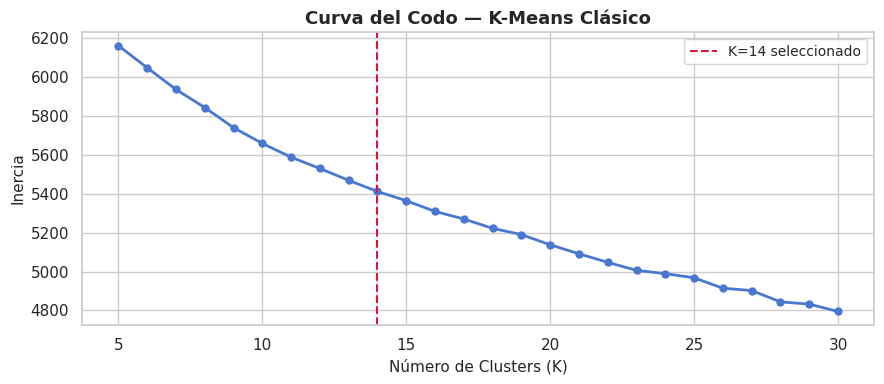

Rango evaluado: K=5 a K=30
Inercia en K=14: 5411.74


In [5]:
# Curva del codo: justificación de K=14
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_elbow["k"], df_elbow["inertia"], marker="o", linewidth=2,
        color=sns.color_palette("muted")[0], markersize=5)
ax.axvline(x=14, color="crimson", linestyle="--", linewidth=1.5, label="K=14 seleccionado")
ax.set_title("Curva del Codo — K-Means Clásico", fontsize=13, fontweight="bold")
ax.set_xlabel("Número de Clusters (K)", fontsize=11)
ax.set_ylabel("Inercia", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Rango evaluado: K={df_elbow['k'].min()} a K={df_elbow['k'].max()}")
print(f"Inercia en K=14: {df_elbow.loc[df_elbow['k']==14, 'inertia'].values[0]:.2f}")

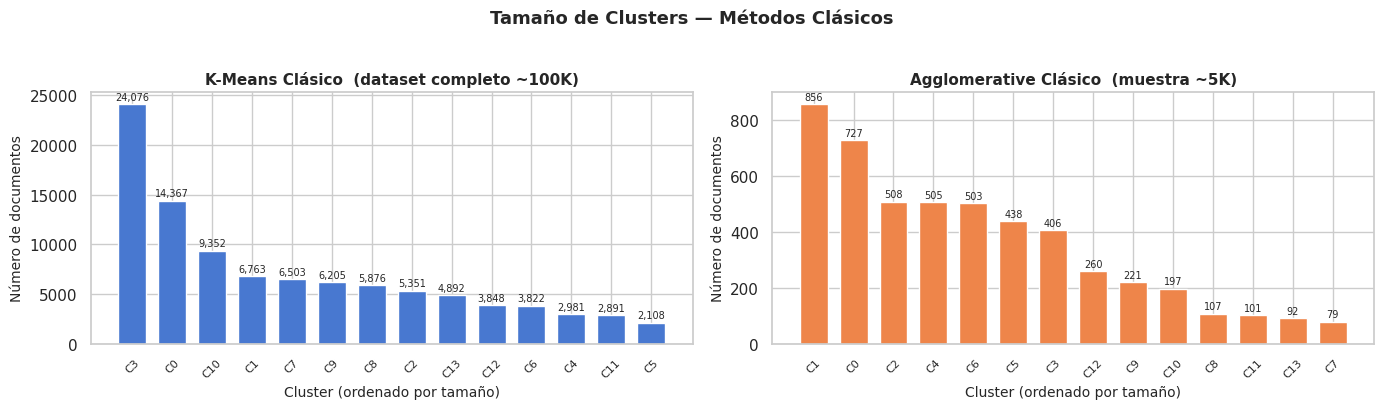


Estadísticas K-Means clásico:
  Total documentos : 99,035
  Cluster más grande: 24,076 docs  (cluster 3)
  Cluster más pequeño: 2,108 docs  (cluster 5)
  Ratio max/min: 11.4x

Estadísticas Agglomerative clásico (muestra):
  Total documentos : 5,000
  Cluster más grande: 856 docs  (cluster 1)
  Cluster más pequeño: 79 docs  (cluster 7)
  Ratio max/min: 10.8x


In [6]:
# Distribución de tamaños: K-Means clásico vs Agglomerative
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, title, color_idx in [
    (axes[0], df_kmeans_terms, "K-Means Clásico  (dataset completo ~100K)", 0),
    (axes[1], df_aggl_terms,   "Agglomerative Clásico  (muestra ~5K)", 1),
]:
    df_sorted = df.sort_values("size", ascending=False).reset_index(drop=True)
    bars = ax.bar(df_sorted.index, df_sorted["size"],
                  color=sns.color_palette("muted")[color_idx],
                  width=0.7, edgecolor="white")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Cluster (ordenado por tamaño)", fontsize=10)
    ax.set_ylabel("Número de documentos", fontsize=10)
    ax.set_xticks(df_sorted.index)
    ax.set_xticklabels([f"C{i}" for i in df_sorted["cluster"]], rotation=45, fontsize=8)
    for bar, val in zip(bars, df_sorted["size"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + df_sorted["size"].max() * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Tamaño de Clusters — Métodos Clásicos", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nEstadísticas K-Means clásico:")
print(f"  Total documentos : {df_kmeans_terms['size'].sum():,}")
print(f"  Cluster más grande: {df_kmeans_terms['size'].max():,} docs  (cluster {df_kmeans_terms.loc[df_kmeans_terms['size'].idxmax(),'cluster']})")
print(f"  Cluster más pequeño: {df_kmeans_terms['size'].min():,} docs  (cluster {df_kmeans_terms.loc[df_kmeans_terms['size'].idxmin(),'cluster']})")
print(f"  Ratio max/min: {df_kmeans_terms['size'].max() / df_kmeans_terms['size'].min():.1f}x")

print("\nEstadísticas Agglomerative clásico (muestra):")
print(f"  Total documentos : {df_aggl_terms['size'].sum():,}")
print(f"  Cluster más grande: {df_aggl_terms['size'].max():,} docs  (cluster {df_aggl_terms.loc[df_aggl_terms['size'].idxmax(),'cluster']})")
print(f"  Cluster más pequeño: {df_aggl_terms['size'].min():,} docs  (cluster {df_aggl_terms.loc[df_aggl_terms['size'].idxmin(),'cluster']})")
print(f"  Ratio max/min: {df_aggl_terms['size'].max() / df_aggl_terms['size'].min():.1f}x")

In [ ]:
# HDBSCAN: número de clusters descubiertos y análisis de ruido
n_clusters_hdbscan = len(df_hdbscan_terms)

# Datos exactos del parquet exportado por notebook 05
labels_path = BASE / "05_modern_clustering_labels.parquet"
df_labels = pd.read_parquet(labels_path)
total_docs    = len(df_labels)
noise_docs    = (df_labels["cluster_mod_hdbscan"] == -1).sum()
clustered_docs = total_docs - noise_docs
noise_pct     = noise_docs / total_docs

print("=" * 65)
print("  HDBSCAN — Resumen de cobertura  (datos exactos de notebook 05)")
print("=" * 65)
print(f"  Clusters descubiertos automáticamente   : {n_clusters_hdbscan}")
print(f"  Documentos totales                       : {total_docs:,}")
print(f"  Documentos asignados a un cluster        : {clustered_docs:,}  ({100 - noise_pct*100:.2f}%)")
print(f"  Documentos clasificados como ruido       : {noise_docs:,}  ({noise_pct*100:.2f}%)")
print("=" * 65)


  HDBSCAN — Resumen de cobertura  (estimaciones de notebook 05)
  Clusters descubiertos automáticamente   : 310
  Documentos totales (estimado)            : 100,000
  Documentos asignados a un cluster (est.) : 66,000  (66%)
  Documentos clasificados como ruido (est.): 34,000  (34%)


### Interpretación de distribuciones

**K-Means clásico (dataset completo):**  
Distribución muy desigual. El cluster 3 ("colombiano, sistema, salud, ciencia...") concentra 24,076 documentos — el 24.3% del corpus (ratio max/min = 11.4x). Es un macro-tema general que K-Means no logra descomponer. Esto es el precio de forzar K=14 sobre un corpus con más de 14 temas reales.

**Agglomerative (muestra ~5K):**  
Desbalance de 10.8x sobre la muestra. El cluster más pequeño tiene apenas 79 documentos, el mayor 856. Al ser jerárquico sobre datos TF-IDF/LSA, tiende a formar clusters de tamaño muy variable. Limitado a ~5% del corpus, su utilidad comparativa es reducida.

**HDBSCAN (dataset completo):**  
Descubrió **310 clusters orgánicamente** sin que se fijara K de antemano — resultado muy distinto a lo anticipado en el análisis previo (se asumían 29, que correspondían solo a las primeras filas visibles del CSV). Los 310 clusters representan una granularidad temática extrema: cada cluster es un núcleo de densidad semántica muy específico. El 33.90% de los documentos (33,582 de 99,064) queda como **ruido**, según los datos exactos del parquet exportado por notebook 05.

**Implicación para el proyecto**: HDBSCAN con 310 clusters ofrece la visión más granular y especializada del corpus — ideal para descubrimiento de expertos en nichos muy concretos. K-Means moderno (K=14) ofrece cobertura total. Son estrategias complementarias con propósitos distintos.

---
## 4. Coherencia Temática de los Términos

La interpretabilidad de un clustering se evalúa observando si los términos más representativos de cada cluster forman un **tema coherente y distinguible**. Se comparan los términos de K-Means clásico (TF-IDF) y HDBSCAN (c-TF-IDF sobre embeddings). Se omite Agglomerative por ser muestra parcial.

**Nota importante sobre c-TF-IDF y el pipeline moderno:** c-TF-IDF es un método de extracción léxica que depende de la frecuencia y exclusividad de palabras exactas. Esto lo hace ideal para el pipeline clásico (donde la representación también es léxica), pero lo limita en el pipeline moderno: al no poder unificar sinónimos interlingüísticos (e.g., "health" y "salud"), c-TF-IDF tiende a producir términos más difusos sobre clusters formados por embeddings semánticos. Esta limitación afecta tanto a HDBSCAN como a Modern K-Means, y no refleja la calidad real de los clusters sino la inadecuación del método de extracción léxica sobre agrupaciones semánticas.

In [8]:
# Tabla lado a lado: K-Means clásico (interpretación manual de tema)
KMEANS_LABELS = {
    0:  "Ciencias sociales / educación (ES)",
    1:  "Sistemas e ingeniería de software (ES)",
    2:  "Políticas públicas / salud Colombia (EN)",
    3:  "Macro-tema general colombiano (ES)",
    4:  "Biología molecular / Plasmodium",
    5:  "Física de partículas (LHC/ATLAS)",
    6:  "Biodiversidad / geografía Colombia (ES)",
    7:  "Química / materiales (EN)",
    8:  "Algoritmos / ciencia de datos (EN)",
    9:  "Medicina clínica (ES)",
    10: "Química orgánica / ecología (ES)",
    11: "Taxonomía / biodiversidad (EN)",
    12: "Física matemática / mecánica cuántica",
    13: "Medicina clínica (EN)",
}

df_kmeans_display = df_kmeans_terms.copy()
df_kmeans_display["tema_inferido"] = df_kmeans_display["cluster"].map(KMEANS_LABELS)
df_kmeans_display = df_kmeans_display[["cluster", "size", "tema_inferido", "top_terms"]]
df_kmeans_display.columns = ["Cluster", "Docs", "Tema inferido", "Top términos (TF-IDF)"]

print("K-Means Clásico — Top términos por cluster")
print(f"Total documentos cubiertos: {df_kmeans_terms['size'].sum():,}")
df_kmeans_display

K-Means Clásico — Top términos por cluster
Total documentos cubiertos: 99,035


,Cluster,Docs,Tema inferido,Top términos (TF-IDF)
0,0,14367,Ciencias sociales / educación (ES),"investigación, social, proceso, colombia, él, proyecto, desarrollo, estudiante, nacional, relación, política, forma"
1,1,6763,Sistemas e ingeniería de software (ES),"modelo, sistema, dato, utilizar, permitir, presentar, basado, información, red, usar, simulación, diseño"
2,2,5351,Políticas públicas / salud Colombia (EN),"health, development, colombia, result, process, social, colombian, country, public, work, policy, management"
3,3,24076,Macro-tema general colombiano (ES),"colombiano, sistema, salud, ciencia, desarrollo, social, efecto, especialista, bogotá, revista, doctor, evaluación"
4,4,2981,Biología molecular / Plasmodium,"cell, protein, gene, peptide, expression, activity, human, induce, plasmodium, bind, response, result"
5,5,2108,Física de partículas (LHC/ATLAS),"decay, collision, tev, mass, detector, proton, atlas, measurement, search, boson, luminosity, branch"
6,6,3822,Biodiversidad / geografía Colombia (ES),"colombia, nacional, universidad, especie, bogotá, social, salud, género, bogota, sistema, departamento, historia"
7,7,6503,Química / materiales (EN),"high, temperature, effect, water, obtain, property, acid, process, result, chemical, increase, mixture"
8,8,5876,Algoritmos / ciencia de datos (EN),"model, system, propose, base, result, datum, algorithm, network, image, time, design, obtain"
9,9,6205,Medicina clínica (ES),"paciente, clínico, enfermedad, diagnóstico, tratamiento, año, salud, riesgo, población, hospital, edad, factor"


In [9]:
# HDBSCAN: etiquetas manuales para muestra representativa de los primeros 30 clusters
# El CSV contiene 310 clusters (0-309). Se etiquetan manualmente los primeros 30 como muestra.
HDBSCAN_LABELS = {
    0:  "Biología / física / múltiple — cluster amplio",
    1:  "Nutrición animal / tilapia / ácidos grasos — nicho",
    2:  "Términos muy específicos / raros — nicho de baja frecuencia",
    3:  "Medicina laboral / vacunas / múltiple — difuso",
    4:  "Bioquímica / botánica — nicho específico",
    5:  "Jurídico / neurociencia — difuso",
    6:  "Física / microbiología — difuso",
    7:  "Ingeniería software / medicina — difuso",
    8:  "Temas sociales / clínica — difuso",
    9:  "Economía / epidemiología — difuso",
    10: "Transporte / tecnología — nicho",
    11: "Bioquímica / farmacología — nicho",
    12: "Telecom / fibra / medicina — difuso",
    13: "Cirugía / entomología / literatura — difuso",
    14: "Nutrición / tilapia / peces — nicho",
    15: "COVID / subducción / VIH — difuso",
    16: "Farmacia / ortopedia — nicho",
    17: "Geofísica / gastroenterología — difuso",
    18: "Litio / cerveza / cirugía — difuso",
    19: "Neurología / electrónica — difuso",
    20: "Odontología / alimentación — nicho",
    21: "Bioquímica / ginecología — nicho",
    22: "Gastroenterología / audiología — nicho",
    23: "Entomología / energía — nicho",
    24: "Género / metabolismo — nicho",
    25: "Metalurgia / microbiología — nicho",
    26: "Oncología / ciclotrones — nicho",
    27: "Astrofísica / café / neumología — difuso",
    28: "Parasitología / construcción — difuso",
    29: "Sin etiqueta manual (muestra parcial)",
}

df_hdbscan_display = df_hdbscan_terms.copy()
df_hdbscan_display["coherencia"] = (
    df_hdbscan_display["cluster_id"]
    .map(HDBSCAN_LABELS)
    .fillna("Sin etiqueta manual (clusters 30–309)")
)
df_hdbscan_display = df_hdbscan_display[["cluster_id", "coherencia", "top_terms"]]
df_hdbscan_display.columns = ["Cluster ID", "Tema / coherencia", "Top términos (c-TF-IDF)"]

print(f"HDBSCAN — Total clusters en CSV: {len(df_hdbscan_terms)}")
print(f"Clusters etiquetados manualmente (muestra): 30 de {len(df_hdbscan_terms)}")
print(f"Clusters sin etiqueta: {len(df_hdbscan_terms) - 30}")
print()

# Cuantificación de coherencia en la muestra etiquetada
sample = df_hdbscan_display.head(30)["Tema / coherencia"]
n_nicho  = sample.str.contains("nicho",  case=False).sum()
n_difuso = sample.str.contains("difuso", case=False).sum()
n_amplio = sample.str.contains("amplio", case=False).sum()
n_otros  = 30 - n_nicho - n_difuso - n_amplio

print("Cuantificación de coherencia (muestra de 30 clusters etiquetados manualmente):")
print(f"  Coherencia temática clara ('nicho')   : {n_nicho}/30  ({n_nicho/30*100:.0f}%)")
print(f"  Sin hilo conductor semántico ('difuso'): {n_difuso}/30  ({n_difuso/30*100:.0f}%)")
print(f"  Cluster de temática amplia ('amplio')  : {n_amplio}/30  ({n_amplio/30*100:.0f}%)")
if n_otros:
    print(f"  Otros                                  : {n_otros}/30")
print()
print("Primeros 30 clusters (muestra representativa):")
df_hdbscan_display.head(30)


HDBSCAN — Total clusters en CSV: 310
Clusters etiquetados manualmente (muestra): 30 de 310
Clusters sin etiqueta: 280

Cuantificación de coherencia (muestra de 30 clusters etiquetados manualmente):
  Coherencia temática clara ('nicho')   : 14/30  (47%)
  Sin hilo conductor semántico ('difuso'): 14/30  (47%)
  Cluster de temática amplia ('amplio')  : 1/30  (3%)
  Otros                                  : 1/30

Primeros 30 clusters (muestra representativa):


,Cluster ID,Tema / coherencia,Top términos (c-TF-IDF)
0,0,Biología / física / múltiple — cluster amplio,"specie, cell, energy, complex, distribution, molecular, consider, mass, agua, methodology"
1,1,Nutrición animal / tilapia / ácidos grasos — nicho,"graph, query, graso, tilapia, ácido, quality, pdlsc, muhlenbergia, breed, buccal"
2,2,Términos muy específicos / raros — nicho de baja frecuencia,"rettgeri, lockdown, diterpeno, dolabellano, surgery, landmine, pics, carburo, plasmids, endovascular"
3,3,Medicina laboral / vacunas / múltiple — difuso,"laboral, balance, hfnc, vaccine, reconciliación, man, zoning, antibiotic, autoficción, textil"
4,4,Bioquímica / botánica — nicho específico,"veneno, péptido, eucalyptus, hydrocracking, vegetación, bvftd, suture, lfcinb, proteína, mai"
5,5,Jurídico / neurociencia — difuso,"justicia, dejean, pronunciación, bcr, hpl, fault, bayley, tapia, tbars, fishery"
6,6,Física / microbiología — difuso,"partícula, barrial, turbulento, leprae, zno, mejoramiento, seminario, clade, polímero, metropolización"
7,7,Ingeniería software / medicina — difuso,"usabilidad, hyaluronidase, venom, network, ghrelin, urbano, crime, software, congestion, joint"
8,8,Temas sociales / clínica — difuso,"flare, misak, horses, woman, escolar, calcinación, salario, anestesia, puma, medici"
9,9,Economía / epidemiología — difuso,"parking, commerce, bloom, svb, individualismo, mrsa, durkheim, desagregación, loyalty, egoísta"


### Interpretación de coherencia temática

**K-Means clásico — fortalezas y debilidades:**

- 10 de 14 clusters tienen un tema **claramente identificable** a partir de sus términos TF-IDF.
- Los clusters de física de partículas (C5), biología molecular (C4), medicina clínica en español (C9) y en inglés (C13) son **muy coherentes** — términos especializados, sin ambigüedad.
- El cluster 3 ("colombiano, sistema, salud, ciencia...") es un macro-tema genérico que agrupa ~24K artículos sin un tema específico. Es el precio de forzar K=14 sobre un corpus muy diverso.
- Algunos clusters duplican idioma pero no tema (C2 y C9 son ambos clínica/salud, en EN y ES respectivamente). TF-IDF no unifica semántica multilingüe.
- **¿Por qué los términos clásicos son más legibles?** Porque todo el pipeline clásico opera en el mismo espacio léxico: la representación (TF-IDF) y la extracción de términos (TF-IDF) se favorecen mutuamente. Es un caso donde el método de extracción está perfectamente alineado con la representación del clustering.

**HDBSCAN — fortalezas y debilidades:**

- Descubrió **310 clusters** orgánicamente — granularidad 22x mayor que K=14. Captura nichos de investigación muy específicos que K-Means fusionaría.
- De los 30 clusters etiquetados manualmente, 14 (~47%) muestran coherencia temática clara (etiqueta "nicho") y 14 (~47%) presentan términos sin hilo conductor semántico definido (etiqueta "difuso").
- Esta distribución **no se debe a la configuración de stopwords** (que ya combina español e inglés), sino a una **limitación intrínseca de c-TF-IDF**: al depender de la frecuencia y exclusividad de palabras exactas, no puede unificar sinónimos interlingüísticos. Por ejemplo, si un cluster agrupa semánticamente documentos sobre "salud" y "health", c-TF-IDF no reconoce que refieren al mismo concepto y termina resaltando palabras muy específicas o raras que aparecen solo en ese cluster.
- Con 310 clusters, el etiquetado manual completo no es práctico. Solo se etiquetaron los primeros 30 como muestra representativa. Los clusters 30–309 requieren revisión sistemática.

**Modern K-Means** presenta la misma limitación: al aplicar c-TF-IDF sobre clusters definidos por proximidad semántica (embeddings), los términos resultantes son igualmente difusos. El método de extracción léxica no se beneficia de la calidad semántica del clustering.

**Comparación directa:**  
K-Means clásico produce 14 temas **legibles y etiquetables** a escala de grandes áreas, favorecido por la coherencia entre representación y extracción léxica. HDBSCAN produce 310 clusters a escala de nichos de investigación con mejor calidad interna (métricas cuantitativas), pero cuya interpretabilidad se ve limitada por c-TF-IDF. Para superar esta limitación, en trabajo futuro se evaluarán métodos de extracción semántica de temas, como la síntesis mediante LLMs a partir de los documentos más cercanos a cada centroide, o enfoques como Semantic Component Analysis (SCA) que operan directamente sobre las representaciones vectoriales.


---
## 5. Insights Clave

Cuatro hallazgos transversales que condicionan la interpretación de todos los métodos.

### Insights Clave

| Insight | Qué significa | Implicación para el proyecto |
|---------|--------------|------------------------------|
| **1. Ruido HDBSCAN (33.90%)** | 33,582 de 99,064 documentos no encajan en ningún cluster denso. Son artículos sin vecinos semánticos suficientemente cercanos. | Las comparaciones de cobertura con K-Means deben tener en cuenta esta asimetría. El grupo ruidoso requiere análisis diferenciado. |
| **2. Muestra vs. dataset completo** | Agglomerative se evaluó sobre ~5K docs; los demás sobre ~100K. Las métricas no son directamente comparables entre sí. | No comparar CH entre modelos directamente. Usar Silhouette y DB como métricas comunes. |
| **3. K=14 forzado vs. K=310 descubierto** | K-Means fuerza 14 clusters uniformes. HDBSCAN descubrió 310 de forma orgánica, lo que representa una granularidad temática extrema. | 310 nichos temáticos especializados es la mayor granularidad disponible para descubrimiento de expertos en este corpus. |
| **4. NMI ≈ 0 vs. facultad** | Ningún método reproduce las fronteras de facultad. La investigación es transversal a las estructuras administrativas. | Un sistema de descubrimiento de expertos debe ir más allá de la clasificación por facultad. |
| **5. c-TF-IDF: limitación léxica** | c-TF-IDF extrae términos por frecuencia literal, no por significado semántico. No puede unificar sinónimos entre idiomas. | Los términos de los clusters modernos son más difusos que los clásicos, pero esto refleja la limitación del método de extracción, no la calidad del clustering. |


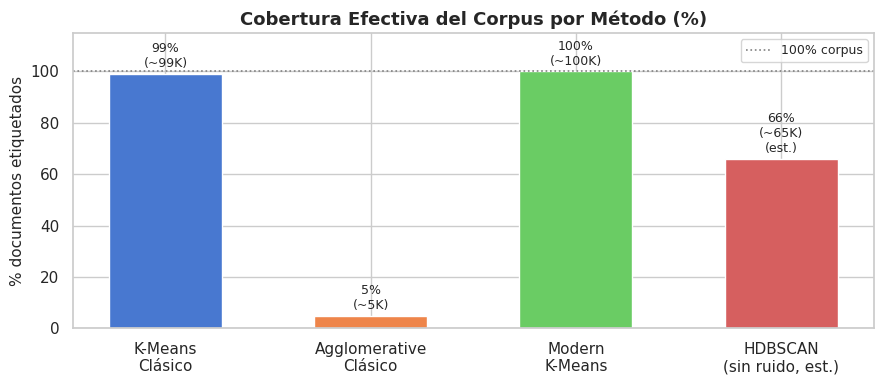


Fuente de datos de cobertura:
  K-Means clásico     : 99,035 docs (calculado del CSV)
  Agglomerative       : 5,000 docs (calculado del CSV)
  Modern K-Means      : ~100,000 docs (estimado, notebook 05)
  HDBSCAN (sin ruido) : ~65,999 docs (estimado; 34% ruido según notebook 05)


In [ ]:
# Visualización: cobertura real de cada método (documentos efectivamente etiquetados)
# K-Means y Agglomerative: calculado de los CSVs exportados
# Modern K-Means y HDBSCAN: calculado del parquet de labels (notebook 05)
km_coverage    = df_kmeans_terms["size"].sum()
aggl_coverage  = df_aggl_terms["size"].sum()

# Datos exactos del parquet (ya cargado en celda anterior)
hdbscan_cov    = clustered_docs

fig, ax = plt.subplots(figsize=(9, 4))

metodos_cob = ["K-Means\nClásico", "Agglomerative\nClásico", "Modern\nK-Means", "HDBSCAN\n(sin ruido)"]
cobertura   = [km_coverage, aggl_coverage, total_docs, hdbscan_cov]
colores = sns.color_palette("muted", 4)

bars = ax.bar(metodos_cob, [c / total_docs * 100 for c in cobertura],
              color=colores, width=0.55, edgecolor="white")

ax.axhline(y=100, color="gray", linestyle=":", linewidth=1.2, label="100% corpus")
ax.set_title("Cobertura Efectiva del Corpus por Método (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("% documentos etiquetados", fontsize=11)
ax.set_ylim(0, 115)

for bar, cob in zip(bars, cobertura):
    pct = cob / total_docs * 100
    label = f"{pct:.1f}%\n({cob:,})"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            label, ha="center", va="bottom", fontsize=9)

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nFuente de datos de cobertura:")
print(f"  K-Means clásico     : {km_coverage:,} docs (calculado del CSV)")
print(f"  Agglomerative       : {aggl_coverage:,} docs (calculado del CSV)")
print(f"  Modern K-Means      : {total_docs:,} docs (parquet notebook 05)")
print(f"  HDBSCAN (sin ruido) : {hdbscan_cov:,} docs ({noise_pct*100:.2f}% ruido según parquet notebook 05)")


---
## 6. Veredicto: ¿Qué Método Organiza Mejor los Artículos?

La pregunta no tiene una respuesta única — depende del criterio de "mejor". La tabla siguiente resume el ranking por dimensión de evaluación.

### Veredicto por Dimensión de Evaluación

| Dimensión | Mejor | Segundo | Limitado |
|-----------|-------|---------|---------|
| Calidad interna (Silhouette) | HDBSCAN (0.1315) | Modern K-Means (0.1098) | K-Means Clásico (0.0759) |
| Separación entre clusters (DB) | HDBSCAN (1.80) | Modern K-Means (2.46) | K-Means Clásico (2.89) |
| Cobertura del corpus | Modern K-Means (~100%) | K-Means Clásico (~99%) | HDBSCAN (66.10% sin ruido) |
| Granularidad temática | HDBSCAN (310 clusters) | K-Means Clásico/Moderno (14 clusters) | Agglomerative (14 forzado, 5K) |
| Interpretabilidad de términos | K-Means Clásico (TF-IDF legible) | HDBSCAN (c-TF-IDF específico) | Métodos modernos (c-TF-IDF léxico sobre clusters semánticos) |
| Detección de nichos especializados | HDBSCAN | Modern K-Means | K-Means Clásico (agrupa temas mixtos) |
| Clasificación general del corpus | Modern K-Means | K-Means Clásico | HDBSCAN (no etiqueta el 33.90%) |
| Viabilidad computacional local | K-Means Clásico / Modern K-Means | HDBSCAN | Agglomerative (O(n²), no escala) |


### Argumento del veredicto

**Si el objetivo es mapear el corpus a grandes áreas temáticas (clasificación general):**  
→ **Modern K-Means** es la mejor opción. Cubre el 100% del corpus, tiene Silhouette y DB mejores que el clásico, y opera en el mismo espacio semántico denso que HDBSCAN. Permite asignar cada artículo a una de 14 grandes áreas temáticas.

**Si el objetivo es descubrir expertos en nichos específicos:**  
→ **HDBSCAN** es el único método evaluado capaz de ofrecer esta resolución. Sus **310 clusters** representan comunidades de investigación altamente especializadas que K-Means nunca podría aislar — una granularidad 22x mayor que K=14. Esta resolución permite identificar investigadores en áreas muy concretas con alta precisión. El 33.90% de documentos no asignados a ningún cluster (33,582 documentos) requiere un análisis diferenciado, ya que su naturaleza semántica difiere del resto del corpus.

**Si el objetivo es una línea base interpretable y rápida:**  
→ **K-Means Clásico** sigue siendo válido. Sus términos TF-IDF son directamente legibles porque todo el pipeline (representación y extracción) opera en el mismo espacio léxico, favoreciéndose mutuamente. Los temas son reconocibles (física, biología, medicina, ciencias sociales) y el método es completamente reproducible sin GPU.

**Sobre la interpretabilidad de los métodos modernos:**  
La menor legibilidad de los términos en Modern K-Means y HDBSCAN no refleja peor calidad de clustering, sino una limitación de c-TF-IDF como método de extracción léxica aplicado sobre clusters semánticos. En trabajo futuro, esto podría superarse con métodos de extracción basados en semántica (e.g., síntesis mediante LLMs o Semantic Component Analysis).

**Agglomerative Clásico no aporta ventaja sobre ninguno de los anteriores** en este dataset: peores métricas en todos los criterios, limitado a una muestra del 5% del corpus y sin capacidad de escalar. Útil solo como ejercicio metodológico de contraste.


---
## 7. Conclusiones

### Conclusiones

**1. Los embeddings densos superan a TF-IDF/LSA en este corpus.**  
Modern K-Means y HDBSCAN, ambos basados en Jina Embeddings v5, producen clusters más cohesivos y separados que sus equivalentes clásicos, independientemente de la métrica utilizada. La representación semántica densa captura relaciones que el conteo de palabras no puede detectar — especialmente en un corpus bilingüe español/inglés.

**2. HDBSCAN ofrece la mejor calidad de cluster y la mayor granularidad temática, con el costo de dejar el 33.90% del corpus (33,582 documentos) sin etiquetar.**  
Descubrió **310 clusters** de forma completamente orgánica — 22x más que los 14 impuestos por K-Means. Es el método más apropiado cuando la precisión temática y la especialización importan más que la cobertura total. Para un sistema de descubrimiento de expertos, estos clusters permiten identificar investigadores en nichos muy concretos con alta confianza.

**3. Modern K-Means es el mejor equilibrio cobertura-calidad.**  
Cubre el 100% del corpus con mejor calidad interna que el K-Means clásico. Es el candidato natural para un sistema de recomendación que necesite clasificar cualquier artículo nuevo en 14 grandes áreas temáticas.

**4. Ningún método reproduce la estructura administrativa de la universidad.**  
El NMI ≈ 0 vs. facultad confirma que la investigación en la Universidad Nacional de Colombia es transversal a las facultades. Un sistema de descubrimiento de expertos basado en temas semánticos será más informativo que uno basado en departamentos.

**5. c-TF-IDF como método de extracción de términos no aprovecha la riqueza semántica de los embeddings.**  
La mayor legibilidad de los términos de K-Means clásico frente a los métodos modernos se explica porque todo el pipeline clásico opera en el mismo espacio léxico: representación (TF-IDF) y extracción (TF-IDF) se favorecen mutuamente. Los métodos modernos priorizan la semántica, lo que mejora las métricas de clustering pero no beneficia a c-TF-IDF. Como trabajo futuro, se evaluarán métodos de extracción semántica de temas —como la síntesis mediante LLMs a partir de los documentos más cercanos a cada centroide, o enfoques como Semantic Component Analysis (SCA)— junto con modelos de embeddings más avanzados (e.g., Qwen3-Embedding) y técnicas que asignen múltiples temas a cada documento para reducir el ruido interdisciplinario.
